In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

In [2]:
sys.path.append('/home/baijayanta/MY_Documented_Code/simvis/')
sys.path.append('/home/baijayanta/MY_Documented_Code/tge/')

In [3]:
import simvis as sv
import grid as gd

Imported simvis, Import Time : 20/05/26 | 05:30:22 PM
Imported Grid, Import Time : 20/05/26 | 05:30:22 PM


In [4]:
# load bining info
BIN = np.load('/home/baijayanta/MY_Documented_Code/tge/bin_info_7200.npz')

In [5]:
# Set the gridding parameters in the TGE code
n1      = 0                  # Starting channel number
n2      = 99                 # End channel number
Flag    = False              # Apply actual flagging of data
Umax    = int(BIN['Umax'])   # Baselines greater than this are rejected
FWHM    = int(BIN['FWHM'])   # Primary beam FWHM of the telescope in degrees
f       = float(BIN['f'])    # Tapering parameter value
nstokes = [0]                # 0 for XX and 1 for YY (polarizations to grid)
# ===================================================
nrel    = -1    # grid along freq axis  
mask = BIN['NI'] >= 0        # mask array
Nbin = int(BIN['Nbin'])      # No of annular bins the whole uv plane has been divided into
ni   = BIN['ni']             # Contains info about which grid point fall into which bin
lval = BIN['lval']           # obtain the ell values

In [6]:
out_uaps_fits = './simulated/1000007200_uaps.fits'   # uaps fits file name
out_aps_fits  = './simulated/1000007200_aps.fits'    #  aps fits file name

In [7]:
GV_APS  = np.squeeze(gd.grid( out_aps_fits,n1,n2,nrel,Umax,FWHM,f,Flag, nstokes)[0]) # grid aps file
GV_UAPS = np.squeeze(gd.grid(out_uaps_fits,n1,n2,nrel,Umax,FWHM,f,Flag, nstokes)[0]) # grid uaps file

<<<<<<<<<<< TGE >>>>>>>>>>>>
<< 20/05/26 | 05:30:22 PM >>
Type  : Data
<< 20/05/26 | 05:30:35 PM >>
Elapsed   :   00:00:12.37
<<<<<<<<<<< Done >>>>>>>>>>>
<<<<<<<<<<< TGE >>>>>>>>>>>>
<< 20/05/26 | 05:30:35 PM >>
Type  : Data
<< 20/05/26 | 05:30:47 PM >>
Elapsed   :   00:00:12.28
<<<<<<<<<<< Done >>>>>>>>>>>


In [8]:
def correlator(GV, ni, Nbin):
    corr = np.zeros((Nbin, GV.shape[-1])) # make an empty array
    for jj in range(Nbin):
        corr[jj] = np.sum(abs(GV[ni == jj])**2, axis = 0) # vcg times vcg*
                                                          # sum over grid points
    return corr

\begin{align}
C_{\ell_g} &= M_g^{-1}\,\left\langle V_{cg}\cdot V_{cg}^{*} \right\rangle\\[0.5em]
M_g        &= \left\langle V_{cg}\cdot V_{cg}^{*} \right\rangle _{\rm UAPS}\\[0.5em]
C_{\ell}   &= \frac{\sum_g\,w_g\,C_{\ell_g}}{\sum_g\, w_g}\,\quad \text{with}\, w_g = M_g
\end{align}

In [9]:
# for aps
eg = correlator(GV_APS[mask], ni, Nbin) 
print(eg.shape)

# for uaps
mg = np.mean(correlator(GV_UAPS[mask], ni, Nbin), axis = 1)
print(mg.shape)

(20, 100)
(20,)


In [10]:
cl    = eg/mg[:,None]   # get APS
model = sv.aps(lval)    # get model value

In [11]:
dcl     = np.std(cl, axis = 1)   # get standard deviation
cl_mean = np.mean(cl, axis = 1)  # get mean value

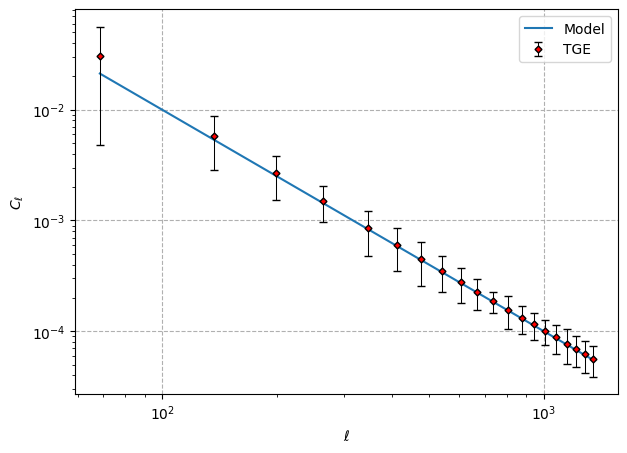

In [12]:
# plot with 2 sigma errorbar
fig = plt.figure(figsize=(7,5))
plt.plot(lval, model, label = "Model")
plt.errorbar(lval, cl_mean, 2*dcl, fmt='D', ms = 3.5, elinewidth = 0.75, \
             capsize = 3, color = 'black', markerfacecolor = 'red', markeredgecolor = 'black', label = "TGE")
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_{\ell}$")
plt.legend()
plt.loglog()
plt.grid(ls = "dashed")
plt.savefig("cl_recovered.pdf", dpi = 500)
plt.show()